In [1]:
# TASK 1:

import pandas as pd

# Loading the dataset
df = pd.read_csv('customer_support_text_classification.csv')

# 1. Number of records
num_records = len(df)

# 2. Target labels/classes
target_labels = df['sentiment_label'].unique().tolist()

# 3. Sample text records (taking the first 3)
sample_records = df['customer_message'].head(3).tolist()

# 4. Average text length
if 'word_count' in df.columns:
    avg_text_length = df['word_count'].mean()
else:
    avg_text_length = df['customer_message'].apply(lambda x: len(str(x).split())).mean()

# 5. Class distribution
class_distribution = df['sentiment_label'].value_counts().to_dict()

# Printing the results
print("--- Dataset Analysis ---")
print(f"Number of records: {num_records}")
print(f"Target labels/classes: {target_labels}")
print(f"Average text length (words): {avg_text_length:.2f}")
print(f"Class distribution: {class_distribution}")

print("\n--- Sample Text Records ---")
for i, record in enumerate(sample_records, 1):
    print(f"{i}. {record}")

--- Dataset Analysis ---
Number of records: 1500
Target labels/classes: ['neutral', 'positive', 'negative']
Average text length (words): 12.72
Class distribution: {'neutral': 524, 'negative': 497, 'positive': 479}

--- Sample Text Records ---
1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
2. I need information about the payment process.
3. The refund process was fast and convenient. I appreciate the quick response.


In [6]:
# TASK 2:

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Downloading NLTK stopwords
nltk.download('stopwords')
nltk.download('punkt')

# STEP 1 & 2: Lowercasing & Special Characters
def clean_text(text):
    # Lowercasing
    text = str(text).lower()
    # Removing numbers and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Removing extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_message'] = df['customer_message'].apply(clean_text)

# STEP 3 & 4: Tokenization & Stopwords

stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    # Splitting by spaces (basic tokenization)
    tokens = text.split()
    # Removing stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

df['tokens'] = df['cleaned_message'].apply(tokenize_and_remove_stopwords)

# STEP 5: Sequences & Padding (For Deep Learning)

max_vocab = 5000  # Number of top words to keep
max_len = 20      # Maximum length of sequences (since average is ~13 words)

# Initializing Keras Tokenizer
tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')

# Fitting on the cleaned texts
tokenizer.fit_on_texts(df['cleaned_message'])

# Converting texts to sequences of integers
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])

# Pading or truncating the sequences to make them all length = 20
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Adding the sequences back to the dataframe
df['padded_sequences'] = list(padded_sequences)

# Preview the results
print(df[['customer_message', 'cleaned_message', 'tokens']].head(3))

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   

                                     cleaned_message  \
0  i need information about the payment process m...   
1       i need information about the payment process   
2  the refund process was fast and convenient i a...   

                                              tokens  
0  [need, information, payment, process, ticket, ...  
1              [need, information, payment, process]  
2  [refund, process, fast, convenient, appreciate...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [9]:
#TASK 3:

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


texts = df['customer_message'].fillna("").astype(str).tolist()

print(f"Total documents to vectorize: {len(texts)}\n")


# Method A: Bag of Words (BoW)
# Creating a matrix where columns are unique words and values are word counts.

bow_vectorizer = CountVectorizer(max_features=1000, stop_words='english')
bow_matrix = bow_vectorizer.fit_transform(texts)

print("--- Bag of Words (BoW) ---")
print(f"BoW Matrix Shape: {bow_matrix.shape}")
print(f"Sample Features (Words): {bow_vectorizer.get_feature_names_out()[:10]}\n")

# Method B: TF-IDF (Term Frequency-Inverse Document Frequency)
# Similar to BoW, but weighs words based on how rare and informative they are.

tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

print("--- TF-IDF ---")
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
# Showing the TF-IDF scores for the first document
print(f"Sample TF-IDF values for document 0: {tfidf_matrix[0].data}\n")

# Method C: Tokenizer-based sequences (For Deep Learning / Word Embeddings)
# Converting each sentence into a sequence of integer IDs (useful for LSTMs/Transformers)

max_vocab = 2000
max_len = 20

tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)

# Converting text to sequences of integers
sequences = tokenizer.texts_to_sequences(texts)

# Pading sequences to ensure uniform length
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

print("--- Tokenizer-Based Sequences (For Embeddings) ---")
print(f"Padded Sequences Shape: {padded_sequences.shape}")
print(f"Sequence for document 0: {padded_sequences[0]}\n")

Total documents to vectorize: 1500

--- Bag of Words (BoW) ---
BoW Matrix Shape: (1500, 619)
Sample Features (Words): ['10347' '10565' '10632' '10783' '10841' '10973' '11045' '11058' '11213'
 '11482']

--- TF-IDF ---
TF-IDF Matrix Shape: (1500, 619)
Sample TF-IDF values for document 0: [0.28970235 0.36133046 0.34353047 0.2911934  0.1634141  0.1690694
 0.60790053 0.22940095 0.22940095 0.22940095]

--- Tokenizer-Based Sequences (For Embeddings) ---
Padded Sequences Shape: (1500, 20)
Sequence for document 0: [  5  30 137  40   2  91  34   4   7   8   3 185  11  13   9  14   9  15
   0   0]



Accuracy: 1.0000

--- Classification Report ---
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



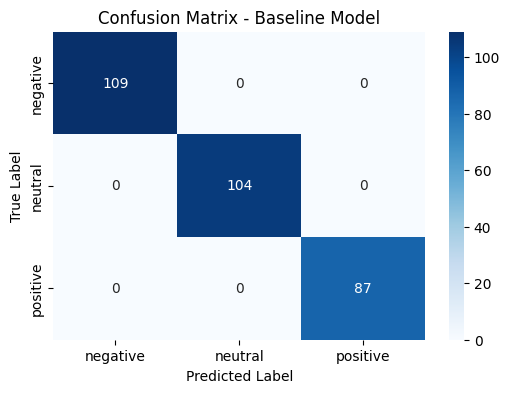

In [11]:
#TASK 4:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Loading data
df = pd.read_csv('customer_support_text_classification.csv')
X = df['customer_message'].fillna("")
y = df['sentiment_label']

# 2. Splitting data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Vectorizing text using TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)  # Note: only .transform() on test data to prevent data leakage

# 4. Initializing and train the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_vec, y_train)

# 5. Evaluating the model
preds = model.predict(X_test_vec)
acc = accuracy_score(y_test, preds)

print(f"Accuracy: {acc:.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_test, preds))

# 6. Plotting a Confusion Matrix
cm = confusion_matrix(y_test, preds, labels=model.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - Baseline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [12]:
#TASK 5:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D

# 1. Load Data
df = pd.read_csv('customer_support_text_classification.csv')
X_text = df['customer_message'].fillna("").astype(str)
y_text = df['sentiment_label']

# 2. Encode Labels (positive, neutral, negative -> 0, 1, 2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

# 3. Tokenize and Pad Sequences
max_vocab = 2000
max_len = 20
tokenizer = Tokenizer(num_words=max_vocab, oov_token='<OOV>')
tokenizer.fit_on_texts(X_text)

X_seq = tokenizer.texts_to_sequences(X_text)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')

# 4. Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# 5. Build LSTM Model
model = Sequential()
model.add(Embedding(input_dim=max_vocab, output_dim=32, input_length=max_len))
model.add(SpatialDropout1D(0.2)) # Drops entire 1D feature maps to prevent overfitting
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(3, activation='softmax'))

# 6. Compile Model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 7. Train Model
print("Training the LSTM model...")
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# 8. Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")

# Optional: View architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training the LSTM model...
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.5517 - loss: 1.0017 - val_accuracy: 0.7667 - val_loss: 0.4774
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9467 - loss: 0.1603 - val_accuracy: 1.0000 - val_loss: 0.0115
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9950 - loss: 0.0189 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9983 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0019
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.0019

Final Test Accuracy: 1.0000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 32)         │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 20, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,083 (1.02 MB)

 Trainable params: 89,027 (347.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 178,056 (695.54 KB)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for argmax
from sklearn.metrics import classification_report, confusion_matrix
# Assume label_encoder, X_test (padded sequences), y_test (numerical), model (LSTM) are available from previous cells

# Getting predictions from the LSTM model
lstm_preds_proba = model.predict(X_test)
lstm_preds_labels_encoded = np.argmax(lstm_preds_proba, axis=1)

# Converting numerical y_test and predicted labels back to original string labels
y_test_str = label_encoder.inverse_transform(y_test)
preds_str = label_encoder.inverse_transform(lstm_preds_labels_encoded)

# --- GENERATING sample_predictions.txt ---
# For sampling, we need the original indices of the X_test from the LSTM split
# Re-do the split to get original indices
from sklearn.model_selection import train_test_split
X_train_indices, X_test_indices, _, _ = train_test_split(
    df.index, y, test_size=0.2, random_state=42, stratify=y
)

# Take 10 random indices from the test set indices
sample_original_indices = np.random.choice(X_test_indices, 10, replace=False)

with open('sample_predictions.txt', 'w') as f:
    f.write("--- SAMPLE MODEL PREDICTIONS ---\n\n")
    for original_idx in sample_original_indices:
        text = df.loc[original_idx, 'customer_message']
        true_label_original = df.loc[original_idx, 'sentiment_label'] # Original string label

        # Getting the numerical index within the X_test_indices array to find corresponding prediction
        idx_in_test_array = np.where(X_test_indices == original_idx)[0][0]

        predicted_label_str = preds_str[idx_in_test_array]

        f.write(f"Message: {text}\n")
        f.write(f"True Label: {true_label_original}\n")
        f.write(f"Predicted Label: {predicted_label_str}\n")
        f.write("-" * 40 + "\n")

print("Saved sample_predictions.txt")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Saved sample_predictions.txt


In [20]:
!pip freeze > requirements.txt